# 06 - Interactive Detector Viewer

Just for fun. None of the code here is important to memorize or use in an analysis.

If the sys.path.append(...) line doesn't work, switch it to the path to your site packages and pip install any of the imports that don't load.


## Interactive Detector Geometry Viewer

In [1]:
import numpy as np
import os
import sys
import glob
import h5py
sys.path.append('/home/ireistr/.local/lib/python3.11/site-packages/')
import plotly.graph_objects as go
import plotly.io as pio
from icecube import dataio

pio.renderers.default = "notebook_connected"

# Input GCD file
GCD_FILE = "/data/exp/IceCube/2020/filtered/level2/0101/Run00133575/Level2_IC86.2019_data_Run00133575_0101_78_503_GCD.i3.zst"

# Read geometry
gcd = dataio.I3File(GCD_FILE)

geometry = None
while gcd.more():
    frame = gcd.pop_frame()
    if "I3Geometry" in frame:
        geometry = frame["I3Geometry"]
        break

if geometry is None:
    raise RuntimeError("Could not find I3Geometry in the GCD file.")

# Collect real in-ice DOM coordinates
# Keep only standard in-ice DOMs: strings 1..86, OMs 1..60
rows = []
for omkey, omgeo in geometry.omgeo:
    string = int(omkey.string)
    om     = int(omkey.om)

    if 1 <= string <= 86 and 1 <= om <= 60:
        p = omgeo.position
        rows.append((string, om, float(p.x), float(p.y), float(p.z)))

if len(rows) == 0:
    raise RuntimeError("No in-ice DOMs found.")

dtype = [
    ("string", np.int32),
    ("om",     np.int32),
    ("x",      np.float64),
    ("y",      np.float64),
    ("z",      np.float64),
]
doms = np.array(rows, dtype=dtype)

# DeepCore strings
DEEPCORE_STRINGS = {79, 80, 81, 82, 83, 84, 85, 86}
is_deepcore = np.array([s in DEEPCORE_STRINGS for s in doms["string"]])
is_main     = ~is_deepcore

# Helper: build line coordinates for each string
def build_string_lines(doms_subset):
    xs, ys, zs = [], [], []
    strings = np.unique(doms_subset["string"])

    for s in strings:
        sel = doms_subset[doms_subset["string"] == s]
        sel = sel[np.argsort(sel["om"])]

        xs.extend(sel["x"].tolist())
        ys.extend(sel["y"].tolist())
        zs.extend(sel["z"].tolist())

        xs.append(None)
        ys.append(None)
        zs.append(None)

    return xs, ys, zs

x_main_line, y_main_line, z_main_line = build_string_lines(doms[is_main])
x_dc_line,   y_dc_line,   z_dc_line   = build_string_lines(doms[is_deepcore])

# Scene extents
xmin, xmax = doms["x"].min(), doms["x"].max()
ymin, ymax = doms["y"].min(), doms["y"].max()
zmin, zmax = doms["z"].min(), doms["z"].max()

xpad = 120
ypad = 120
zpad = 120

xmin_plot, xmax_plot = xmin - xpad, xmax + xpad
ymin_plot, ymax_plot = ymin - ypad, ymax + ypad
zmin_plot, zmax_plot = zmin - zpad, zmax + zpad

# Approximate surface in IceCube coordinates
Z_SURFACE = 1946.0

# Surface plane
x_plane = np.array([[xmin_plot, xmax_plot],
                    [xmin_plot, xmax_plot]])
y_plane = np.array([[ymin_plot, ymin_plot],
                    [ymax_plot, ymax_plot]])
z_plane = np.array([[Z_SURFACE, Z_SURFACE],
                    [Z_SURFACE, Z_SURFACE]])

# Coordinate axes from origin
axis_len = 350.0

axis_traces = [
    go.Scatter3d(
        x=[0, axis_len], y=[0, 0], z=[0, 0],
        mode="lines",
        line=dict(width=8, color="red"),
        name="x-axis",
        hoverinfo="skip",
        showlegend=False,
    ),
    go.Scatter3d(
        x=[0, 0], y=[0, axis_len], z=[0, 0],
        mode="lines",
        line=dict(width=8, color="limegreen"),
        name="y-axis",
        hoverinfo="skip",
        showlegend=False,
    ),
    go.Scatter3d(
        x=[0, 0], y=[0, 0], z=[0, axis_len],
        mode="lines",
        line=dict(width=8, color="deepskyblue"),
        name="z-axis",
        hoverinfo="skip",
        showlegend=False,
    ),
    go.Scatter3d(
        x=[axis_len + 40], y=[0], z=[0],
        mode="text",
        text=["x"],
        textfont=dict(size=18, color="red"),
        hoverinfo="skip",
        showlegend=False,
    ),
    go.Scatter3d(
        x=[0], y=[axis_len + 40], z=[0],
        mode="text",
        text=["y"],
        textfont=dict(size=18, color="limegreen"),
        hoverinfo="skip",
        showlegend=False,
    ),
    go.Scatter3d(
        x=[0], y=[0], z=[axis_len + 40],
        mode="text",
        text=["+z"],
        textfont=dict(size=18, color="deepskyblue"),
        hoverinfo="skip",
        showlegend=False,
    ),
    go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode="markers+text",
        marker=dict(size=6, color="yellow"),
        text=["origin"],
        textposition="top center",
        textfont=dict(size=14, color="white"),
        hoverinfo="skip",
        showlegend=False,
    )
]

# Build figure

fig = go.Figure()

# Surface plane
fig.add_trace(
    go.Surface(
        x=x_plane,
        y=y_plane,
        z=z_plane,
        showscale=False,
        opacity=0.20,
        colorscale=[[0, "lightgray"], [1, "lightgray"]],
        hoverinfo="skip",
        name="surface",
    )
)

# Main array string lines
fig.add_trace(
    go.Scatter3d(
        x=x_main_line,
        y=y_main_line,
        z=z_main_line,
        mode="lines",
        line=dict(color="rgba(180,180,220,0.35)", width=2),
        name="main strings",
        hoverinfo="skip",
    )
)

# DeepCore string lines
fig.add_trace(
    go.Scatter3d(
        x=x_dc_line,
        y=y_dc_line,
        z=z_dc_line,
        mode="lines",
        line=dict(color="rgba(0,255,255,0.85)", width=5),
        name="DeepCore strings",
        hoverinfo="skip",
    )
)

# Main array DOMs
fig.add_trace(
    go.Scatter3d(
        x=doms["x"][is_main],
        y=doms["y"][is_main],
        z=doms["z"][is_main],
        mode="markers",
        marker=dict(
            size=2.7,
            color=doms["z"][is_main],
            colorscale="Blues",
            opacity=0.55,
            showscale=False,
        ),
        name="main DOMs",
        customdata=np.stack([doms["string"][is_main], doms["om"][is_main]], axis=-1),
        hovertemplate=(
            "string %{customdata[0]}<br>"
            "OM %{customdata[1]}<br>"
            "x=%{x:.1f} m<br>"
            "y=%{y:.1f} m<br>"
            "z=%{z:.1f} m<extra></extra>"
        ),
    )
)

# DeepCore DOMs
fig.add_trace(
    go.Scatter3d(
        x=doms["x"][is_deepcore],
        y=doms["y"][is_deepcore],
        z=doms["z"][is_deepcore],
        mode="markers",
        marker=dict(
            size=4.0,
            color="cyan",
            opacity=0.95,
        ),
        name="DeepCore DOMs",
        customdata=np.stack([doms["string"][is_deepcore], doms["om"][is_deepcore]], axis=-1),
        hovertemplate=(
            "DeepCore<br>"
            "string %{customdata[0]}<br>"
            "OM %{customdata[1]}<br>"
            "x=%{x:.1f} m<br>"
            "y=%{y:.1f} m<br>"
            "z=%{z:.1f} m<extra></extra>"
        ),
    )
)

# Axes overlays
for tr in axis_traces:
    fig.add_trace(tr)

# Layout
fig.update_layout(
    title="IceCube in-ice detector geometry from real GCD coordinates",
    template="plotly_dark",
    width=1100,
    height=900,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor="rgba(0,0,0,0.35)"
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis=dict(
            title="x [m]",
            range=[xmin_plot, xmax_plot],
            backgroundcolor="rgb(8,8,20)",
            gridcolor="rgba(255,255,255,0.10)",
            zerolinecolor="rgba(255,255,255,0.20)",
        ),
        yaxis=dict(
            title="y [m]",
            range=[ymin_plot, ymax_plot],
            backgroundcolor="rgb(8,8,20)",
            gridcolor="rgba(255,255,255,0.10)",
            zerolinecolor="rgba(255,255,255,0.20)",
        ),
        zaxis=dict(
            title="z [m]",
            range=[zmin_plot, zmax_plot],
            backgroundcolor="rgb(5,12,28)",
            gridcolor="rgba(255,255,255,0.10)",
            zerolinecolor="rgba(255,255,255,0.20)",
        ),
        aspectmode="data",
        camera=dict(
            eye=dict(x=1.65, y=-1.55, z=0.95)
        ),
    ),
)

fig.show()

# Optional:
# fig.write_html("icecube_real_geometry_3d.html")

/cvmfs/icecube.opensciencegrid.org/py3-v4.3.0/Ubuntu_22.04_x86_64/lib/python3.11/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.2) or chardet (7.4.3)/charset_normalizer (3.1.0) doesn't match a supported version!
  warnings.warn(


## Event Viewer For Multiple Frames

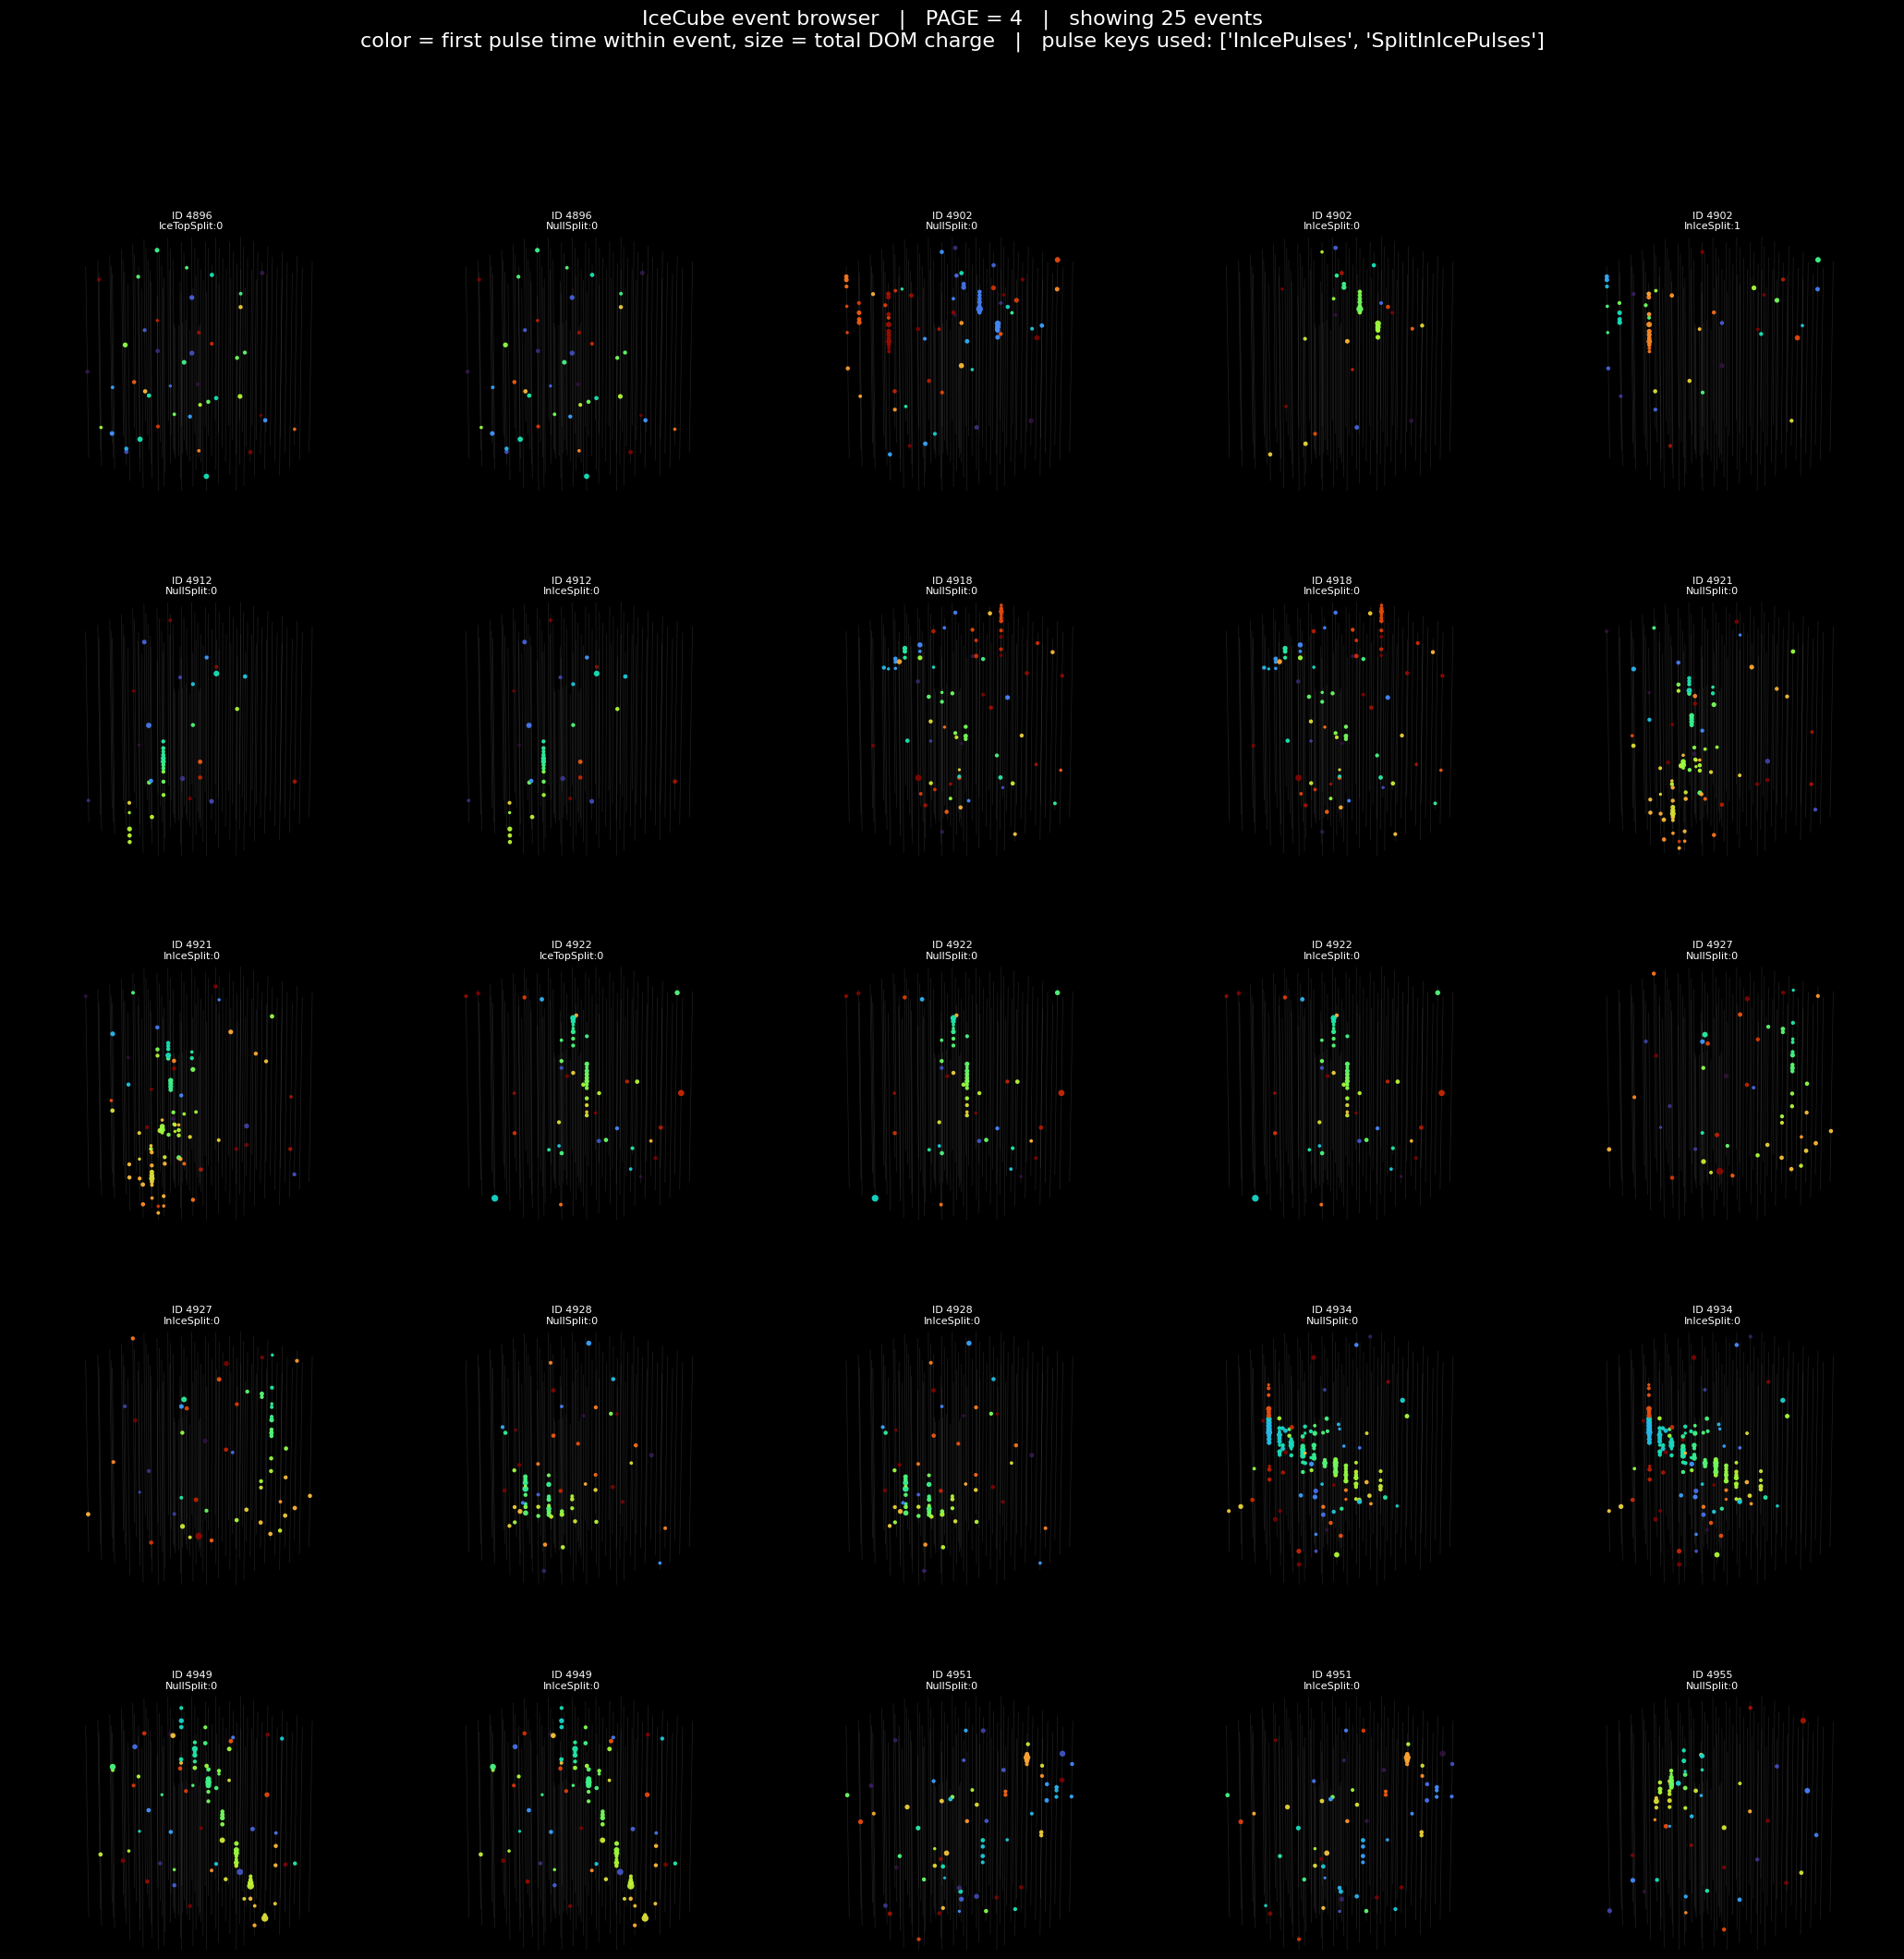

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from icecube import dataio, dataclasses, icetray

# USER INPUT
# ============================================================
GCD_FILE = "/data/exp/IceCube/2020/filtered/level2/0101/Run00133575/Level2_IC86.2019_data_Run00133575_0101_78_503_GCD.i3.zst"
EVENT_FILE = "/data/exp/IceCube/2020/filtered/level2/0101/Run00133575/Level2_IC86.2019_data_Run00133575_Subrun00000000_00000000.i3.zst"

PAGE = 4                  # 0 = first 25 events, 1 = next 25, etc.
NROWS, NCOLS = 5, 5
EVENTS_PER_PAGE = NROWS * NCOLS

MIN_HIT_DOMS = 0          # raise to ~40, 60, 80 if you want only busier/prettier events
MIN_TOTAL_CHARGE = 0.0    # optional extra filter

# Set this to "InIceSplit" if you want only that sub-event stream
REQUIRE_SUB_EVENT_STREAM = None

PULSE_KEY_CANDIDATES = [
    "SplitInIcePulses",
    "SRTInIcePulses",
    "TWSRTOfflinePulses",
    "OfflinePulses",
    "MaskedOfflinePulses",
    "InIcePulses",
    "InIceDSTPulses",
]

# HELPERS
# ============================================================
def load_geometry(gcd_file):
    f = dataio.I3File(gcd_file)
    while f.more():
        fr = f.pop_frame()
        if fr.Stop == icetray.I3Frame.Geometry:
            return fr["I3Geometry"]
    raise RuntimeError("Could not find Geometry frame in GCD file.")

def is_inice_dom(omkey):
    return 1 <= omkey.om <= 60

def get_detector_data(geo):
    omgeo = geo.omgeo
    all_x, all_y, all_z = [], [], []
    dom_records = []
    for omkey, om in omgeo.items():
        if is_inice_dom(omkey):
            x, y, z = om.position.x, om.position.y, om.position.z
            all_x.append(x)
            all_y.append(y)
            all_z.append(z)
            dom_records.append((int(omkey.string), x, y, z))
    return np.array(all_x), np.array(all_y), np.array(all_z), dom_records

def group_strings(dom_records):
    by_string = {}
    for string, x, y, z in dom_records:
        by_string.setdefault(string, []).append((x, y, z))
    for s in by_string:
        by_string[s] = sorted(by_string[s], key=lambda p: p[2])
    return by_string

def try_get_pulses(frame, pulse_candidates):
    for key in pulse_candidates:
        if key in frame:
            try:
                pulses = dataclasses.I3RecoPulseSeriesMap.from_frame(frame, key)
                return key, pulses
            except Exception:
                pass
    return None, None

def extract_hit_info(geo, pulses):
    omgeo = geo.omgeo

    hit_x, hit_y, hit_z = [], [], []
    qtot_list, tfirst_list = [], []

    for omkey, pulse_series in pulses:
        if not is_inice_dom(omkey):
            continue
        if omkey not in omgeo:
            continue
        if len(pulse_series) == 0:
            continue

        pos = omgeo[omkey].position
        qtot = np.sum([p.charge for p in pulse_series])
        tfirst = np.min([p.time for p in pulse_series])

        hit_x.append(pos.x)
        hit_y.append(pos.y)
        hit_z.append(pos.z)
        qtot_list.append(qtot)
        tfirst_list.append(tfirst)

    hit_x = np.array(hit_x)
    hit_y = np.array(hit_y)
    hit_z = np.array(hit_z)
    qtot = np.array(qtot_list)
    tfirst = np.array(tfirst_list)

    if len(tfirst) > 0:
        tfirst = tfirst - np.min(tfirst)

    return hit_x, hit_y, hit_z, qtot, tfirst

def get_event_label(frame):
    if "I3EventHeader" not in frame:
        return "NoHeader"

    hdr = frame["I3EventHeader"]
    event_id = getattr(hdr, "event_id", "NA")
    sub_event_id = getattr(hdr, "sub_event_id", None)
    sub_event_stream = getattr(hdr, "sub_event_stream", None)

    if sub_event_id is not None and sub_event_stream not in [None, ""]:
        return f"ID {event_id}\n{sub_event_stream}:{sub_event_id}"
    return f"ID {event_id}"

def event_passes_filters(frame, hit_x, qtot):
    if len(hit_x) < MIN_HIT_DOMS:
        return False
    if np.sum(qtot) < MIN_TOTAL_CHARGE:
        return False

    if REQUIRE_SUB_EVENT_STREAM is not None:
        if "I3EventHeader" not in frame:
            return False
        hdr = frame["I3EventHeader"]
        if getattr(hdr, "sub_event_stream", None) != REQUIRE_SUB_EVENT_STREAM:
            return False

    return True

def collect_page_of_events(event_file, geo, page=0, events_per_page=25):
    """
    Reads through Physics frames, keeps only frames with readable pulses
    and enough activity, then returns one page of events.
    """
    f = dataio.I3File(event_file)

    wanted_start = page * events_per_page
    qualifying_count = 0
    selected = []

    while f.more():
        fr = f.pop_frame()
        if fr.Stop != icetray.I3Frame.Physics:
            continue

        pulse_key, pulses = try_get_pulses(fr, PULSE_KEY_CANDIDATES)
        if pulses is None:
            continue

        hit_x, hit_y, hit_z, qtot, tfirst = extract_hit_info(geo, pulses)
        if len(hit_x) == 0:
            continue

        if not event_passes_filters(fr, hit_x, qtot):
            continue

        if qualifying_count >= wanted_start and len(selected) < events_per_page:
            selected.append({
                "frame": fr,
                "pulse_key": pulse_key,
                "label": get_event_label(fr),
                "hit_x": hit_x,
                "hit_y": hit_y,
                "hit_z": hit_z,
                "qtot": qtot,
                "tfirst": tfirst,
            })

        qualifying_count += 1

        if len(selected) >= events_per_page:
            break

    return selected, qualifying_count

def draw_event(ax, event, string_lines, xlim, ylim, zlim):
    # Background
    ax.set_facecolor("black")

    # Faint detector strings
    for pts in string_lines.values():
        x = [p[0] for p in pts]
        y = [p[1] for p in pts]
        z = [p[2] for p in pts]
        ax.plot(x, y, z, color=(0.35, 0.35, 0.35), lw=0.5, alpha=0.35)

    qtot = event["qtot"]
    tfirst = event["tfirst"]

    # Marker size scaling
    sizes = 4 + 20 * np.log10(qtot + 1.0)

    # Make times visually comparable within each event
    # Use robust upper bound so one late pulse does not wash out the colors
    if len(tfirst) > 0:
        vmax = np.percentile(tfirst, 95)
        if vmax <= 0:
            vmax = 1.0
    else:
        vmax = 1.0

    ax.scatter(
        event["hit_x"], event["hit_y"], event["hit_z"],
        c=tfirst,
        s=sizes,
        cmap="turbo",
        vmin=0,
        vmax=vmax,
        alpha=0.95,
        edgecolors="none",
        depthshade=False,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)

    try:
        # ax.set_box_aspect([xlim[1]-xlim[0], ylim[1]-ylim[0], zlim[1]-zlim[0]])
        # ax.set_box_aspect([xlim[1]-xlim[0], ylim[1]-ylim[0], zlim[1]-zlim[0]], zoom=1.8)
        xspan = xlim[1] - xlim[0]
        yspan = ylim[1] - ylim[0]
        zspan = zlim[1] - zlim[0]
        
        ax.set_box_aspect([xspan, yspan, 1.0*zspan], zoom=1.8)
    except Exception:
        pass

    ax.view_init(elev=16, azim=35)
    ax.set_axis_off()
    ax.set_title(event["label"], fontsize=8, color="white", y=0.77, pad=2)

# LOAD GEOMETRY
# ============================================================
geo = load_geometry(GCD_FILE)
all_x, all_y, all_z, dom_records = get_detector_data(geo)
string_lines = group_strings(dom_records)

xmin, xmax = np.min(all_x), np.max(all_x)
ymin, ymax = np.min(all_y), np.max(all_y)
zmin, zmax = np.min(all_z), np.max(all_z)

pad_xy = 20
pad_z = 10

xlim = (xmin - pad_xy, xmax + pad_xy)
ylim = (ymin - pad_xy, ymax + pad_xy)
# zlim = (zmin - pad_z, zmax + pad_z)
zlim = (zmin - 600, zmax - 250)

# COLLECT ONE PAGE OF EVENTS
# ============================================================
events, n_seen = collect_page_of_events(
    EVENT_FILE,
    geo,
    page=PAGE,
    events_per_page=EVENTS_PER_PAGE
)

if len(events) == 0:
    raise RuntimeError(
        "No qualifying events found for this page.\n"
        "Try PAGE=0, or reduce MIN_HIT_DOMS / MIN_TOTAL_CHARGE, or check the pulse keys."
    )

# PLOT 5x5 GRID
# ============================================================
# fig = plt.figure(figsize=(18, 18), facecolor="black")
fig = plt.figure(figsize=(21, 21), facecolor="black")

for i in range(EVENTS_PER_PAGE):
    ax = fig.add_subplot(NROWS, NCOLS, i + 1, projection="3d")

    if i < len(events):
        draw_event(ax, events[i], string_lines, xlim, ylim, zlim)
    else:
        ax.set_facecolor("white")
        ax.set_axis_off()

pulse_keys_used = sorted(set(ev["pulse_key"] for ev in events))

fig.suptitle(
    f"IceCube event browser   |   PAGE = {PAGE}   |   showing {len(events)} events\n"
    f"color = first pulse time within event, size = total DOM charge   |   pulse keys used: {pulse_keys_used}",
    color="white",
    fontsize=16,
    y=1.01
)

fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.95,
                    wspace=0.00, hspace=0.00)


# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()